In [ ]:
import pandas as pd

df = pd.read_csv('/content/processed_insurance.csv')

X = df.drop('charges', axis=1)
y = df['charges']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_tuned = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

rf_tuned.fit(X_train, y_train)

RandomForestRegressor(max_depth=10, min_samples_leaf=2, min_samples_split=5,
                      n_estimators=300, random_state=42)

In [ ]:
y_pred_tuned = rf_tuned.predict(X_test)

In [ ]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

mae_tuned = mean_absolute_error(y_test, y_pred_tuned)
mse_tuned = mean_squared_error(y_test, y_pred_tuned)
r2_tuned = r2_score(y_test, y_pred_tuned)

print("Optimized Random Forest Results")
print("MAE:", mae_tuned)
print("MSE:", mse_tuned)
print("R² Score:", r2_tuned)

Optimized Random Forest Results
MAE: 2441.703376422246
MSE: 19519656.06905859
R² Score: 0.8937740848394926


In [ ]:
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "Optimized Random Forest"
    ],
    "R2 Score": [
        0.8068,
        0.8924,
        0.8834,
        r2_tuned
    ]
})

comparison

,Model,R2 Score
0,Linear Regression,0.806800
1,Decision Tree,0.892400
2,Random Forest,0.883400
3,Optimized Random Forest,0.893774


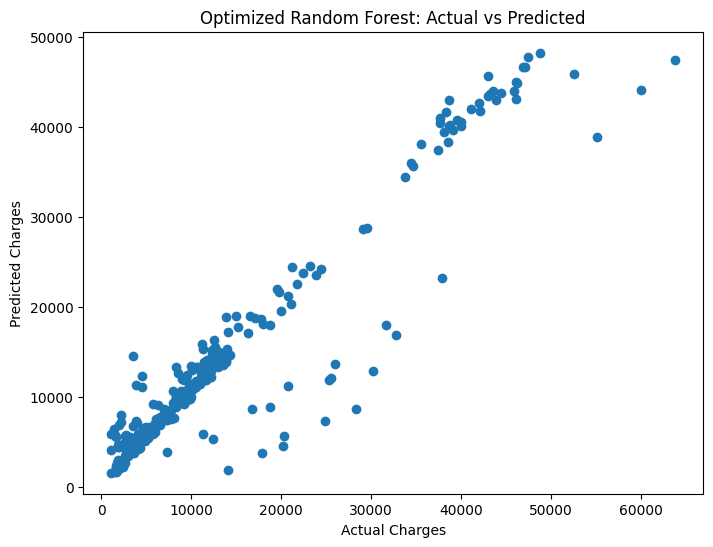

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_tuned)

plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Optimized Random Forest: Actual vs Predicted")

plt.show()

In [ ]:
import joblib

joblib.dump(
    rf_tuned,
    'optimized_random_forest.pkl'
)

['optimized_random_forest.pkl']